# Generate mock analytics data

This notebook creates synthetic usage data for the business dashboard.

The data represents simulated parent searches and venue activity. It is intended only for demonstrating the MVP and does not represent real users or confirmed customer behaviour.

In [56]:
%pip install matplotlib
import pandas as pd
import random

from datetime import datetime, timedelta
from pathlib import Path

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\zasht\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Set a random seed

A fixed random seed ensures that the notebook generates the same demo data each time it is run.

In [57]:
random.seed(42)

## Configure the mock dataset

The mock dataset will cover the previous 60 days.

The IDs below must correspond to records in the development database. The current seeded database contains parent users with IDs 2 and 3, five sample venues and ten amenities.

In [58]:
number_of_searches = 300
number_of_days = 60

user_ids = [2, 3]
venue_ids = [1, 2, 3, 4, 5]
amenity_ids = list(range(1, 11))

categories = [
    "catering.cafe",
    "catering.restaurant",
    "entertainment.museum",
    "leisure.playground"
]

output_directory = Path("../mock")
output_directory.mkdir(parents=True, exist_ok=True)

## Generate mock search events

Each record represents a parent searching the app.

Searches are given a simulated user, date and time, location, category and number of results. The generated coordinates are located approximately around Hertfordshire.

In [59]:
search_events = []

end_date = datetime.now()
start_date = end_date - timedelta(days=number_of_days)

for search_id in range(1, number_of_searches + 1):
    random_days = random.randint(0, number_of_days - 1)

    search_hour = random.choices(
        population=[8, 10, 12, 14, 16, 18],
        weights=[5, 15, 30, 25, 15, 10],
        k=1
    )[0]

    searched_at = (
        start_date
        + timedelta(days=random_days)
    ).replace(
        hour=search_hour,
        minute=random.randint(0, 59),
        second=0,
        microsecond=0
    )

    search_events.append({
        "id": search_id,
        "user_id": random.choice(user_ids),
        "latitude": round(random.uniform(51.70, 51.95), 6),
        "longitude": round(random.uniform(-0.45, 0.15), 6),
        "radius": random.choice([5000, 10000, 15000]),
        "category": random.choice(categories),
        "result_count": random.randint(5, 30),
        "searched_at": searched_at
    })

search_events_df = pd.DataFrame(search_events)

display(search_events_df.head())
print(f"{len(search_events_df)} mock search events created")

,id,user_id,latitude,longitude,radius,category,result_count,searched_at
0,1,3,51.761223,-0.366277,5000,catering.cafe,23,2026-09-08 10:47:00
1,2,2,51.758165,-0.088789,15000,catering.restaurant,27,2026-08-26 08:05:00
2,3,2,51.812302,-0.283086,5000,catering.restaurant,27,2026-09-09 14:26:00
3,4,2,51.939303,-0.248043,5000,leisure.playground,8,2026-08-26 12:09:00
4,5,3,51.901782,-0.012161,15000,catering.cafe,17,2026-08-21 16:38:00


300 mock search events created


## Review the mock search data

The date range and category counts are checked to ensure that the generated dataset is suitable for the dashboard.

In [60]:
print("First date:", search_events_df["searched_at"].min())
print("Last date:", search_events_df["searched_at"].max())

display(
    search_events_df["category"].value_counts()
)

First date: 2026-07-30 10:09:00
Last date: 2026-09-27 14:44:00


category
leisure.playground      90
catering.restaurant     73
entertainment.museum    72
catering.cafe           65
Name: count, dtype: int64

## Generate requested amenities

Each search will include between one and three requested amenities.

The amenities are weighted so that family-focused facilities such as changing facilities, pram access and high chairs appear more frequently. This creates realistic patterns for the demonstration dashboard.

In [61]:
amenity_names = {
    1: "Accessible entrance",
    2: "Accessible toilet",
    3: "Prams allowed",
    4: "Pram storage",
    5: "Changing facilities",
    6: "Table reservation",
    7: "Breastfeeding friendly",
    8: "Children's activities",
    9: "Parking",
    10: "High chairs"
}

amenity_weights = {
    1: 10,
    2: 14,
    3: 22,
    4: 12,
    5: 28,
    6: 8,
    7: 18,
    8: 16,
    9: 12,
    10: 20
}

## Link amenities to search events

Each selected amenity creates one record in `search_event_amenities`.

A set is used to prevent the same amenity from being added to the same search more than once.

In [62]:
search_event_amenities = []

weighted_amenity_ids = []

for amenity_id, weight in amenity_weights.items():
    weighted_amenity_ids.extend([amenity_id] * weight)

for search_id in search_events_df["id"]:
    number_requested = random.choices(
        population=[1, 2, 3],
        weights=[50, 35, 15],
        k=1
    )[0]

    selected_amenities = set()

    while len(selected_amenities) < number_requested:
        selected_amenities.add(
            random.choice(weighted_amenity_ids)
        )

    for amenity_id in selected_amenities:
        search_event_amenities.append({
            "search_event_id": search_id,
            "amenity_id": amenity_id
        })

search_event_amenities_df = pd.DataFrame(
    search_event_amenities
)

display(search_event_amenities_df.head())

print(
    f"{len(search_event_amenities_df)} "
    "search-amenity records created"
)

,search_event_id,amenity_id
0,1,5
1,2,2
2,3,8
3,4,9
4,4,7


501 search-amenity records created


## Review amenity demand

The number of searches requesting each amenity is calculated.

These figures will support the “Most requested amenities” section of the business dashboard.

In [63]:
amenity_demand = (
    search_event_amenities_df
    .groupby("amenity_id")
    .size()
    .reset_index(name="search_count")
)

amenity_demand["amenity_name"] = (
    amenity_demand["amenity_id"]
    .map(amenity_names)
)

amenity_demand = amenity_demand.sort_values(
    "search_count",
    ascending=False
)

display(
    amenity_demand[
        ["amenity_name", "search_count"]
    ]
)

,amenity_name,search_count
4,Changing facilities,86
6,Breastfeeding friendly,75
2,Prams allowed,71
9,High chairs,60
7,Children's activities,54
1,Accessible toilet,52
8,Parking,33
3,Pram storage,27
5,Table reservation,22
0,Accessible entrance,21


## Generate mock venue views

A venue view represents a parent opening a venue's details page.

Views are generated using the same users and date range as the search events. Some venues are given higher probabilities to simulate differences in popularity.

In [64]:
number_of_views = 180

venue_popularity = {
    1: 30,
    2: 25,
    3: 20,
    4: 15,
    5: 10
}

weighted_venue_ids = []

for venue_id, weight in venue_popularity.items():
    weighted_venue_ids.extend([venue_id] * weight)

## Create the venue-view records

Each venue view is linked to a demo user and a venue.

The view time is based on a randomly selected search time, with a short delay added to represent the user opening a venue after searching.

In [65]:
venue_views = []

for view_id in range(1, number_of_views + 1):
    related_search = search_events_df.sample(
        n=1,
        random_state=random.randint(1, 100000)
    ).iloc[0]

    viewed_at = (
        related_search["searched_at"]
        + timedelta(minutes=random.randint(1, 20))
    )

    venue_views.append({
        "id": view_id,
        "venue_id": random.choice(weighted_venue_ids),
        "user_id": related_search["user_id"],
        "viewed_at": viewed_at
    })

venue_views_df = pd.DataFrame(venue_views)

display(venue_views_df.head())

print(f"{len(venue_views_df)} mock venue views created")

,id,venue_id,user_id,viewed_at
0,1,1,2,2026-07-30 11:06:00
1,2,4,2,2026-09-25 18:48:00
2,3,5,2,2026-09-09 11:02:00
3,4,1,3,2026-09-25 12:57:00
4,5,4,2,2026-09-17 14:51:00


180 mock venue views created


## Review venue popularity

The number of views for each venue is counted.

These totals can be displayed in the business dashboard and used to compare engagement between venues.

In [66]:
venue_view_counts = (
    venue_views_df
    .groupby("venue_id")
    .size()
    .reset_index(name="view_count")
    .sort_values("view_count", ascending=False)
)

display(venue_view_counts)

,venue_id,view_count
1,2,49
0,1,45
2,3,35
3,4,32
4,5,19


## Export the mock analytics data

The generated datasets are saved as CSV files so they can be reviewed and imported into the development database.

These files contain simulated data and must not be described as real customer activity.

In [67]:
search_events_df.to_csv(
    output_directory / "search_events_mock.csv",
    index=False
)

search_event_amenities_df.to_csv(
    output_directory / "search_event_amenities_mock.csv",
    index=False
)

venue_views_df.to_csv(
    output_directory / "venue_views_mock.csv",
    index=False
)

print("Mock analytics files saved:")
print(output_directory / "search_events_mock.csv")
print(output_directory / "search_event_amenities_mock.csv")
print(output_directory / "venue_views_mock.csv")

Mock analytics files saved:
..\mock\search_events_mock.csv
..\mock\search_event_amenities_mock.csv
..\mock\venue_views_mock.csv


# Venue analytics (mock data)

This section uses mock searches, views and venue locations to demonstrate the dashboard. The venue IDs and amenities follow the sample SQL seed you provided. Venue names and coordinates are illustrative and do not represent actual venue locations. Nearby interest and amenity gaps are simulated, not observed customer behaviour. Views have no search ID, so they cannot be used to calculate search-to-view conversion.


## Views per venue and over time


,views
venue_id,
2,49
1,45
3,35
4,32
5,19


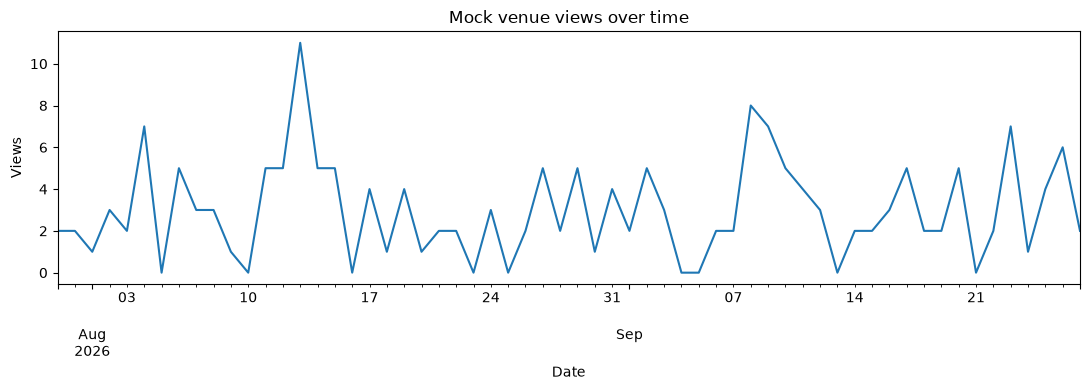

In [68]:
import matplotlib.pyplot as plt

views_by_venue = venue_views_df.groupby("venue_id").size().rename("views")
display(views_by_venue.sort_values(ascending=False).to_frame())

views_by_day = (
    venue_views_df.assign(day=pd.to_datetime(venue_views_df["viewed_at"]).dt.floor("D"))
    .groupby("day").size().rename("views")
)
views_by_day = views_by_day.reindex(
    pd.date_range(views_by_day.index.min(), views_by_day.index.max(), freq="D"),
    fill_value=0
)
ax = views_by_day.plot(figsize=(11, 4), title="Mock venue views over time")
ax.set(xlabel="Date", ylabel="Views")
plt.tight_layout()
plt.show()


## When parents search


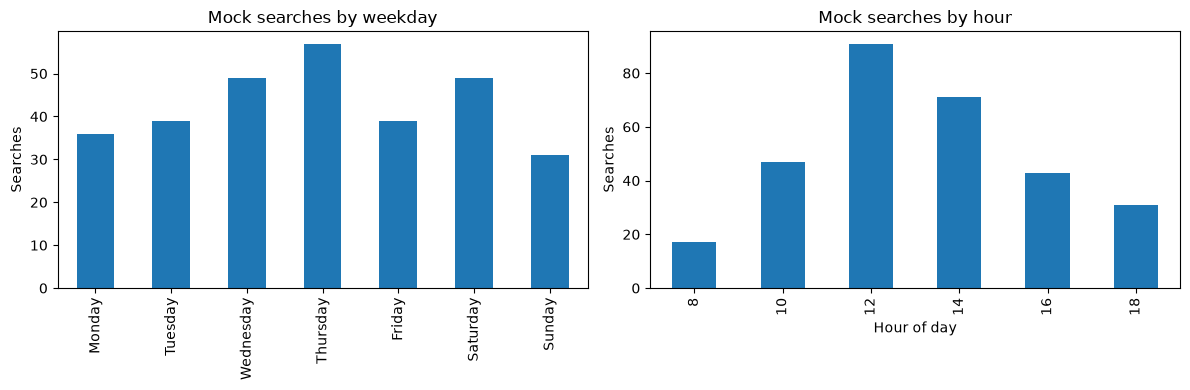

In [69]:
search_times = pd.to_datetime(search_events_df["searched_at"])
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
searches_by_day = search_times.dt.day_name().value_counts().reindex(day_order, fill_value=0)
searches_by_hour = search_times.dt.hour.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
searches_by_day.plot.bar(ax=axes[0], title="Mock searches by weekday")
searches_by_hour.plot.bar(ax=axes[1], title="Mock searches by hour")
axes[0].set(xlabel="", ylabel="Searches")
axes[1].set(xlabel="Hour of day", ylabel="Searches")
plt.tight_layout()
plt.show()


## Create the five mock venues and their amenities

The IDs and venue-amenity links follow the SQL seed. The names and coordinates below are mock values around Hertfordshire. No additional CSV files or database connection are needed.


In [70]:
venues_df = pd.DataFrame([
    {"id": 1, "name": "Mock venue 1", "latitude": 51.7520, "longitude": -0.3370},
    {"id": 2, "name": "Mock venue 2", "latitude": 51.8000, "longitude": -0.2000},
    {"id": 3, "name": "Mock venue 3", "latitude": 51.8550, "longitude": -0.1500},
    {"id": 4, "name": "Mock venue 4", "latitude": 51.9100, "longitude": -0.2200},
    {"id": 5, "name": "Mock venue 5", "latitude": 51.8800, "longitude": -0.0300},
])

venue_amenities_df = pd.DataFrame([
    (1, 1), (1, 2),
    (2, 1), (2, 2), (2, 5),
    (3, 2), (3, 4),
    (4, 1), (4, 3), (4, 5),
    (5, 1), (5, 2), (5, 3), (5, 4),
], columns=["venue_id", "amenity_id"])

display(venues_df)


,id,name,latitude,longitude
0,1,Mock venue 1,51.752,-0.337
1,2,Mock venue 2,51.800,-0.200
2,3,Mock venue 3,51.855,-0.150
3,4,Mock venue 4,51.910,-0.220
4,5,Mock venue 5,51.880,-0.030


In [71]:
mock_venue_names = {
    1: "Little Oak Café",
    2: "The Family Table",
    3: "Storybook Museum",
    4: "Willow Play Café",
    5: "Riverside Family Hub",
}

venues_df["name"] = venues_df["id"].map(mock_venue_names)
display(venues_df[["id", "name"]])

,id,name
0,1,Little Oak Café
1,2,The Family Table
2,3,Storybook Museum
3,4,Willow Play Café
4,5,Riverside Family Hub


## Mock searches near each venue

For each simulated search, calculate the straight-line distance to each mock venue. A search counts as nearby when the mock venue falls inside its radius. One search may count for several venues. These results depend on the illustrative coordinates above; they do not describe real venue demand.


In [72]:
import numpy as np

nearby = search_events_df[["id", "latitude", "longitude", "radius", "searched_at"]].merge(
    venues_df[["id", "name", "latitude", "longitude"]],
    how="cross", suffixes=("_search", "_venue")
)
lat1, lon1 = np.radians(nearby["latitude_search"]), np.radians(nearby["longitude_search"])
lat2, lon2 = np.radians(nearby["latitude_venue"]), np.radians(nearby["longitude_venue"])
dlat, dlon = lat2 - lat1, lon2 - lon1
a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
nearby["distance_metres"] = 6371000 * 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))
nearby_searches = nearby.loc[nearby["distance_metres"] <= nearby["radius"]].rename(
    columns={"id_search": "search_event_id", "id_venue": "venue_id", "name": "venue_name"}
)
venue_summary = venues_df[["id", "name"]].rename(columns={"id": "venue_id", "name": "venue_name"})
venue_summary = venue_summary.merge(
    nearby_searches.groupby("venue_id").size().rename("nearby_searches"),
    on="venue_id", how="left"
).merge(views_by_venue.rename_axis("venue_id"), on="venue_id", how="left")
venue_summary[["nearby_searches", "views"]] = venue_summary[["nearby_searches", "views"]].fillna(0).astype(int)
display(venue_summary.sort_values("nearby_searches", ascending=False))


,venue_id,venue_name,nearby_searches,views
2,3,Storybook Museum,110,35
1,2,The Family Table,95,49
4,5,Riverside Family Hub,84,19
3,4,Willow Play Café,75,32
0,1,Little Oak Café,64,45


## Most requested amenities near each venue


In [73]:
nearby_requests = nearby_searches[["venue_id", "venue_name", "search_event_id"]].merge(
    search_event_amenities_df, on="search_event_id", how="inner", validate="many_to_many"
)
amenity_counts = (
    nearby_requests.groupby(["venue_id", "venue_name", "amenity_id"])
    .size().rename("request_count").reset_index()
)
amenity_counts["amenity_name"] = amenity_counts["amenity_id"].map(amenity_names)
display(amenity_counts.sort_values(["venue_id", "request_count"], ascending=[True, False]))


,venue_id,venue_name,amenity_id,request_count,amenity_name
4,1,Little Oak Café,5,22,Changing facilities
2,1,Little Oak Café,3,18,Prams allowed
6,1,Little Oak Café,7,16,Breastfeeding friendly
7,1,Little Oak Café,8,14,Children's activities
9,1,Little Oak Café,10,12,High chairs
1,1,Little Oak Café,2,11,Accessible toilet
5,1,Little Oak Café,6,6,Table reservation
8,1,Little Oak Café,9,6,Parking
0,1,Little Oak Café,1,3,Accessible entrance
3,1,Little Oak Café,4,3,Pram storage


## Mock amenity gaps at each venue

Compare requests from nearby mock searches with the seeded venue-amenity links. These are demonstration gaps only: the search preferences and venue coordinates were generated for the mock dataset.


In [74]:
venue_amenity_pairs = pd.MultiIndex.from_frame(
    venue_amenities_df[["venue_id", "amenity_id"]]
)
amenity_counts["venue_has_amenity"] = pd.MultiIndex.from_frame(
    amenity_counts[["venue_id", "amenity_id"]]
).isin(venue_amenity_pairs)
gaps = amenity_counts.loc[~amenity_counts["venue_has_amenity"]].sort_values(
    ["venue_id", "request_count"], ascending=[True, False]
)
display(gaps[["venue_name", "amenity_name", "request_count"]])


,venue_name,amenity_name,request_count
4,Little Oak Café,Changing facilities,22
2,Little Oak Café,Prams allowed,18
6,Little Oak Café,Breastfeeding friendly,16
7,Little Oak Café,Children's activities,14
9,Little Oak Café,High chairs,12
5,Little Oak Café,Table reservation,6
8,Little Oak Café,Parking,6
3,Little Oak Café,Pram storage,3
12,The Family Table,Prams allowed,28
16,The Family Table,Breastfeeding friendly,20


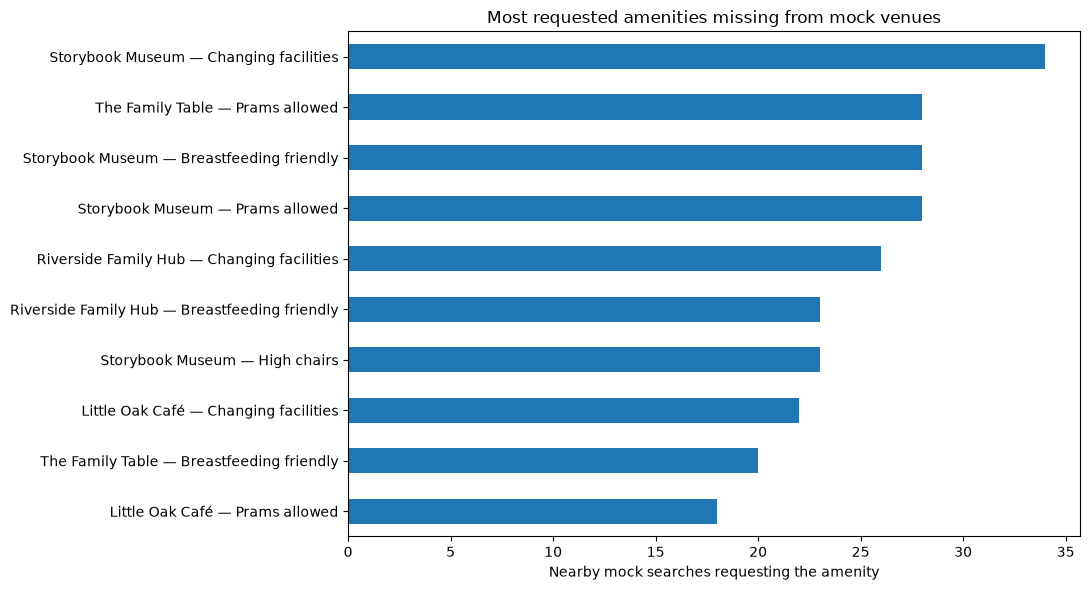

In [75]:
top_gaps = gaps.nlargest(10, "request_count").copy()
top_gaps["label"] = top_gaps["venue_name"] + " — " + top_gaps["amenity_name"]

ax = top_gaps.sort_values("request_count").plot.barh(
    x="label",
    y="request_count",
    figsize=(11, 6),
    legend=False,
    title="Most requested amenities missing from mock venues"
)
ax.set(xlabel="Nearby mock searches requesting the amenity", ylabel="")
plt.tight_layout()
plt.show()